In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit 
import scipy.stats as norm
from sympy import diff, symbols
from scipy import constants as c
import sympy as sp
import math as m
from collections import Counter
import glob
import seaborn as sns
import matplotlib.ticker as ticker
import scipy.optimize as optimize
from scipy.optimize import minimize

/tmp/ipykernel_144559/405033490.py:91: RuntimeWarning: divide by zero encountered in log
  lnftc = -np.log(ft_check)


0
Iteration #2 ft_next: [2.03059208 4.22801035 2.39712238 ... 8.50734486 8.50734486 8.50734486]


/tmp/ipykernel_144559/405033490.py:102: RuntimeWarning: divide by zero encountered in log
  ft_next = -np.log(ft_check)


184
Iteration #3 ft_next: [ 4.06118416  8.45602071  4.79424475 ... 17.01468971 17.01468971
 17.01468971]
184
Iteration #4 ft_next: [ 6.09177623 12.68403106  7.19136713 ... 25.52203457 25.52203457
 25.52203457]
184
Iteration #5 ft_next: [ 8.12236831 16.91204142  9.5884895  ... 34.02937942 34.02937942
 34.02937942]
184
Iteration #6 ft_next: [10.15296039 21.14005177 11.98561188 ... 42.53672428 42.53672428
 42.53672428]
184
Iteration #7 ft_next: [12.18355247 25.36806213 14.38273425 ... 51.04406913 51.04406913
 51.04406913]
184
Iteration #8 ft_next: [14.21414454 29.59607248 16.77985663 ... 59.55141399 59.55141399
 59.55141399]
184
Iteration #9 ft_next: [16.24473662 33.82408284 19.17697901 ... 68.05875884 68.05875884
 68.05875884]
184
Iteration #10 ft_next: [18.2753287  38.05209319 21.57410138 ... 76.5661037  76.5661037
 76.5661037 ]
7625


(0.0, 25000.0)

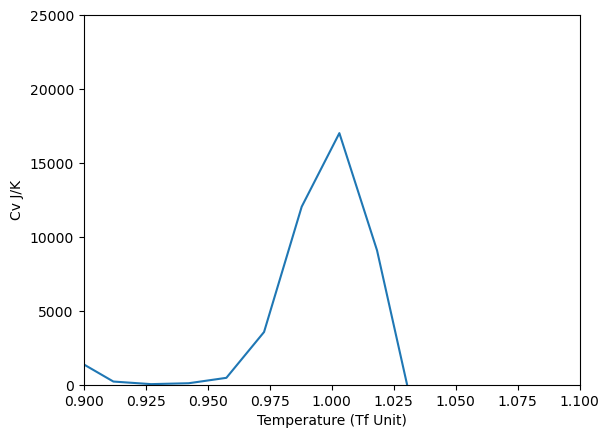

In [181]:
import numpy as np
import scipy.optimize as opt
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.constants as c
import random
import math as m
import matplotlib.ticker as ticker
# Calculations and convergence criteria adapted from Swendsen and Ferrenberg (1989)
# WHAM calclations adapted from Roche et al. (2016)
#
#
#
# Load data
#def wham(tmps, wrkdir):
#xvg_files = glob.glob(f'{wrkdir}/*.xvg')
# still need to make .xvg genie
xvg_files = glob.glob('/mnt/c/users/t_m_w/moleculardynamics/1ubqcalpha/clusterruns/table85/*.xvg')
# remove tmps variable before wrapping
tmps = np.arange(120, 182, 1)
beta = [c.k * i for i in tmps]

bins_init = 75
dp_init = 7625

# 
#bin_opt = 0
#dp_opt = 0
ft_opt = 0

def dataproc(xvg_files, bins, dp):
    xs, ys = [], []
    for file, b in zip(xvg_files, beta):
        data = np.loadtxt(file, comments=['@', '#'], usecols=(1,))
        output = sns.histplot(data=data, stat='probability', bins=bins)
        patches = output.patches
        bin_edges = [patch.get_x() for patch in patches]
        ro = [patch.get_height() for patch in patches]

        for i, v in enumerate(ro):
            if v > 0:
                si = i
                break

        yval = np.array(ro[si:])
        xval = np.array(bin_edges[si:]) * b
        xs.append(xval)
        ys.append(yval)

    xs = np.concatenate(xs)
    ys = np.concatenate(ys)
    indices = np.argsort(xs)
    xs, ys = xs[indices], ys[indices]
    # Ensure xs and ys are divisible by dp
    if len(xs) % dp != 0:
        dp = max([d for d in range(1, dp + 1) if len(xs) % d == 0])
    # Define x and y as values divisible by dp and reshape
    valid_length = (len(xs) // dp) * dp
    xs = xs[:valid_length]
    ys = ys[:valid_length]
    xs = np.reshape(xs, (-1, dp))
    ys = np.reshape(ys, (-1, dp))
    return xs, ys

def whamcv(bins, ft, dp, xs, ys):
    # Optimize bins, ft and dp independently 
    
    # Calculate degeneracy
    
    gk = [np.sum(j) / np.sum(np.exp(i - k)) for i, j, k in zip(xs, ys, ft)]
    # Generate temperature scale array to match gk
    t = np.linspace(tmps.min(), tmps.max(), len(gk))
    # Calculate partition function
    z = [np.sum(np.log1p(i) * np.exp(-j * k)) for i, j, k in zip(gk, xs, beta)]
    # Calculate <Energy>
    E = (c.k * t ** 2) * np.gradient(np.log1p(z), t)
    # Calculate Heat Capactiy
    Cv = np.gradient(E, t)
    # Cv.max() check for optimization
    return Cv, ft

def mgmt(Cv_init,bins_init, ft_new, dp_init):
    xs, ys = dataproc(xvg_files, bins_init, dp_init)
    tol = 0.1
    u = 1
    while True:
        
        for m, n, k in zip(xs, ys, ft_new):
            ft_check = [np.sum(i*(np.exp(j-k))*np.exp(j)) for i, j, k in zip(n, m, ft_new)]
            lnftc = -np.log(ft_check)
        ft_tol = np.isclose(ft_new, lnftc, atol=tol, rtol=tol, equal_nan=False)
        print(np.sum(ft_tol))
        if all(ft_tol) == True:
            ft_opt = ft
            
            break
        else:
            
            u += 1
            ft_next = []
            ft_next = -np.log(ft_check)
            print('Iteration #'+str(u) + ' ft_next: ' + str(ft_next))
            Cv, ft_new = whamcv(bins_init, ft_next, dp_init, xs, ys)
    return ft_opt

ft_init = np.zeros(len(xs[0]))
Cv_init, ft_new = whamcv(bins_init, ft_init, dp_init, xs, ys)
ft_use = mgmt(Cv_init,bins_init, ft_new, dp_init)

cv_use, ft_used = whamcv(bins_init, ft_use, dp_init, xs, ys)
plt.clf()
tmps = np.linspace(tmps.min(), tmps.max(), len(cv_use))
tr = tmps/138.5
plt.plot(tr, cv_use*c.N_A)
plt.xlabel('Temperature (Tf Unit)')
""" plt.plot(tmps, cv_use*c.N_A)
plt.xlabel('Temperature (K)') """
plt.ylabel('Cv J/K')
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(5000))
plt.xlim(0.9, 1.1)
plt.ylim(0, 25000)
